<a href="https://colab.research.google.com/github/liaalcantara01/CDA-UTEC/blob/main/Lab7_2_SVM_LagunaJunin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Máquinas de Soporte Vectorial (SVM)
## Ciencia de Datos Ambientales – Clasificación de la Laguna Junín

**Duración:** 75 minutos

Referencia: [documentación de SVM en scikit-learn](https://scikit-learn.org/stable/modules/svm.html)

---

### Objetivos de aprendizaje

1. Explicar qué es un hiperplano, un margen y un vector de soporte, y cómo se relacionan con la clasificación.
2. Describir por qué se necesita el truco del kernel y qué hace el kernel RBF.
3. Interpretar el parámetro de regularización $C$ y su efecto en la frontera de decisión.
4. Construir e interpretar una curva ROC y calcular el AUC.
5. Entrenar un clasificador SVM en `scikit-learn` y evaluar su rendimiento — caso real: **Laguna Junín**.

> **Tarea:** al final de este notebook aplicarás el mismo flujo de trabajo para clasificar un **glaciar peruano**.

## 1. Encontrar la Mejor Frontera de Decisión

Comencemos con un conjunto de datos simple de dos clases y preguntémonos: *¿cómo deberíamos trazar la línea que separa las clases?*

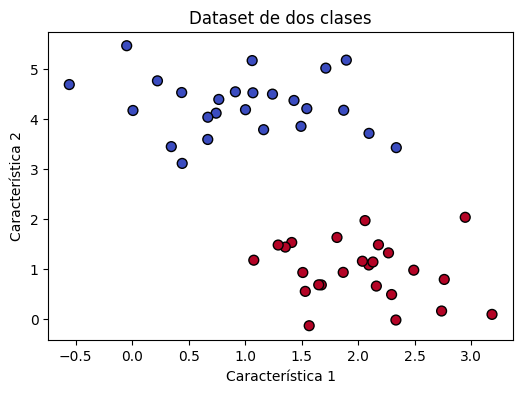

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Two well-separated clusters
X, y = make_blobs(n_samples=50, centers=2, random_state=0, cluster_std=0.6)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.title("Dataset de dos clases")
plt.show()

Imagina que estás mapeando dos tipos de hábitat —por ejemplo, **humedal** frente a **tierra alta**— basándote en dos índices espectrales. Cada píxel es un punto en este espacio de características bidimensional, y quieres una línea que los separe.

Muchas líneas podrían funcionar. Pero, ¿cuál es la mejor?

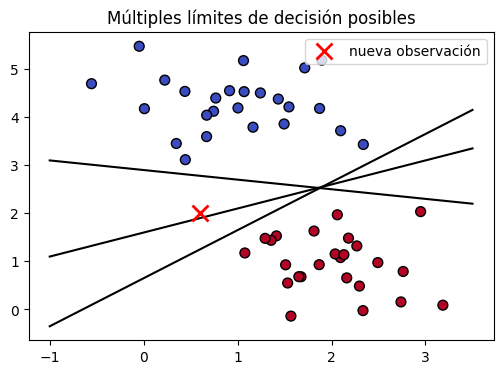

In [ ]:
import numpy as np

xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)

# Tres límites de decisión candidatos
for m, b in [(1, 0.65), (0.5, 1.6), (-0.2, 2.9)]:
    plt.plot(xfit, m * xfit + b, "k-")

# Un nuevo punto ambiguo
plt.plot(0.6, 2, "rx", markersize=12, markeredgewidth=2, label="nueva observación")
plt.legend()
plt.title("Múltiples límites de decisión posibles")
plt.show()

Cada una de esas tres líneas separa correctamente los datos de entrenamiento. Sin embargo, la "x" roja se clasificaría de forma diferente según la línea que elijamos, por lo que la elección es importante.

**Conclusión clave:** Debemos preferir la línea que deja la *mayor separación* (llamada **margen**) entre las clases. Un margen más amplio hace que el clasificador sea más robusto ante nuevos datos y reduce la probabilidad de sobreajuste.

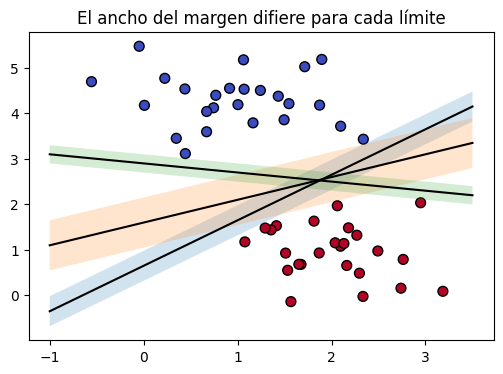

In [ ]:
import numpy as np

xfit = np.linspace(-1, 3.5)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=50)

# Mostrar la banda de margen para cada línea candidata
for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, "k-")
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor="none", alpha=0.2)

plt.title("El ancho del margen difiere para cada límite")
plt.show()

La línea central tiene el **margen más amplio**. El algoritmo que encuentra este límite de margen máximo es la **Máquina de Vectores de Soporte (SVM)**.

## 2. Ajustar una SVM

Vamos a usar `scikit-learn` para encontrar el límite óptimo y visualizar el margen y los vectores de soporte.


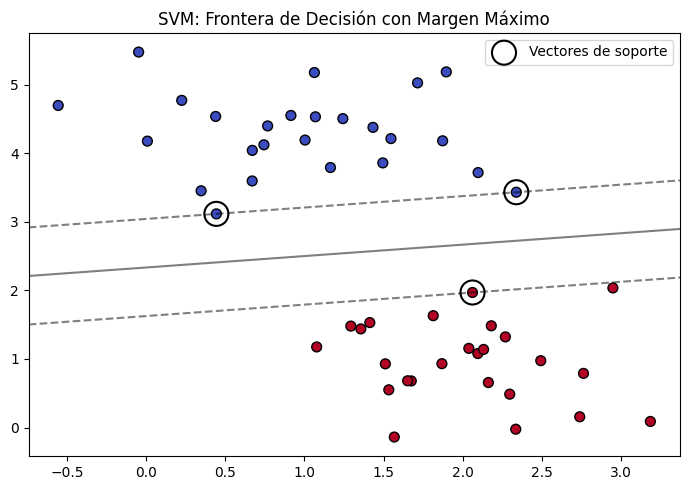

Número de vectores de soporte: 3
Coordenadas de los vectores de soporte:
[[0.44359863 3.11530945]
 [2.33812285 3.43116792]
 [2.06156753 1.96918596]]


In [ ]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt

# Ajustar SVM lineal con margen máximo
modelo_svm = SVC(kernel='linear', C=1e10)
modelo_svm.fit(X, y)

def graficar_svm(modelo, ax=None, mostrar_soporte=True):
    """Grafica frontera de decisión, márgenes y vectores de soporte."""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    Z = modelo.decision_function(np.vstack([XX.ravel(), YY.ravel()]).T).reshape(XX.shape)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    if mostrar_soporte:
        ax.scatter(modelo.support_vectors_[:, 0], modelo.support_vectors_[:, 1],
                   s=300, edgecolors='k', facecolors='none', linewidths=1.5,
                   label='Vectores de soporte')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50)
graficar_svm(modelo_svm, ax)
ax.set_title('SVM: Frontera de Decisión con Margen Máximo')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Número de vectores de soporte: {len(modelo_svm.support_vectors_)}")
print(f"Coordenadas de los vectores de soporte:\n{modelo_svm.support_vectors_}")

### Terminología clave

- **Hiperplano:** el límite de decisión. En 2D es una línea; en 3D, un plano; en dimensiones superiores, un *hiperplano*.

- **Margen:** la distancia entre el hiperplano y los puntos de datos más cercanos de cada clase. La SVM maximiza este margen.

- **Vectores de soporte:** los puntos de entrenamiento que se encuentran exactamente sobre los límites del margen. Solo ellos determinan la posición y orientación del hiperplano; se pueden eliminar todos los demás puntos sin que cambie el resultado.

### Cómo funciona la SVM (pasos conceptuales)

1. **Representar los datos** en un espacio de características de $M$ dimensiones (un eje por característica).

2. **Buscar el hiperplano** que separa las dos clases con el **mayor margen**.

3. **Identificar los vectores de soporte**: los puntos más cercanos al hiperplano que definen el margen.
4. **Resolver el problema de optimización**: matemáticamente, SVM maximiza el margen sujeto a la restricción de que todos los puntos de entrenamiento estén en el lado correcto (o dentro de una tolerancia controlada por el parámetro $C$).

## 3. ¿Qué pasa si los datos no son separables linealmente?

Muchos conjuntos de datos del mundo real no se pueden separar mediante una línea recta. Considere esta disposición circular:

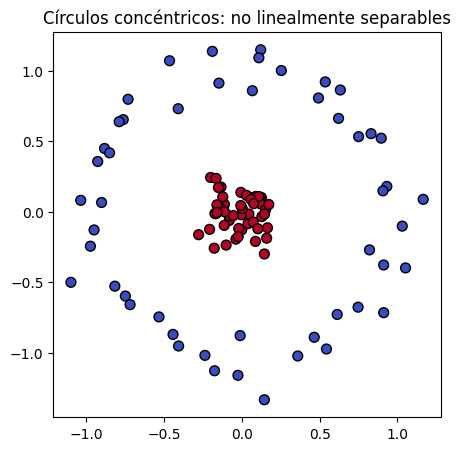

In [ ]:
from sklearn.datasets import make_circles

X_circ, y_circ = make_circles(100, factor=0.1, noise=0.1, random_state=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm",

edgecolors="k", s=50)
ax.set_title("Círculos concéntricos: no linealmente separables")
plt.show()

Una SVM lineal fallará aquí:

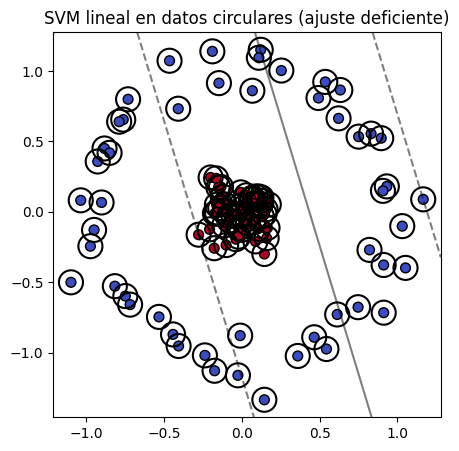

In [ ]:
from sklearn.svm import SVC
clf_lin = SVC(kernel="linear").fit(X_circ, y_circ)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap="coolwarm",
           edgecolors="k", s=50)

graficar_svm(clf_lin, ax, mostrar_soporte=True) #
ax.set_title("SVM lineal en datos circulares (ajuste deficiente)")
plt.show()

### Proyección a una dimensión superior

El truco consiste en **añadir una nueva característica** que permita la separación lineal de las clases en un espacio de mayor dimensión. Por ejemplo, podemos calcular una función de base radial (distancia al origen):

$$
r_i = \exp\!\Bigl(-\sum_j x_{ij}^2\Bigr)
$$

Los puntos cercanos al centro obtienen un valor $r$ alto; los puntos alejados del centro obtienen un valor $r$ bajo. En este nuevo espacio tridimensional ($x_1, x_2, r$), los dos anillos se separan verticalmente, y un plano puede cortarlos.

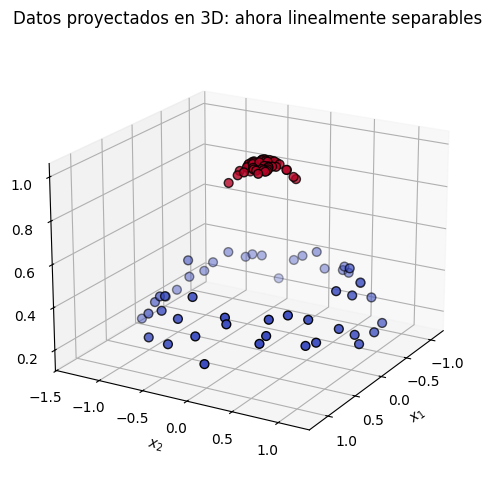

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Calcular la característica de base radial
r = np.exp(-(X_circ ** 2).sum(axis=1))
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_circ[:, 0], X_circ[:, 1], r, c=y_circ, cmap="coolwarm",

edgecolors="k", s=40)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$r$")
ax.set_title("Datos proyectados en 3D: ahora linealmente separables")
ax.view_init(elev=20, azim=30)
plt.tight_layout()
plt.show()

### El Truco del Kernel

Calcular explícitamente nuevas características para cada par de puntos puede resultar costoso (imagínese miles de características). El **truco del kernel** evita esto calculando productos escalares en el espacio de alta dimensión *sin construir dicho espacio explícitamente*. El algoritmo SVM solo necesita estos productos escalares (denominados **valores del kernel**) para encontrar el hiperplano óptimo.

El truco del kernel mapea los datos a un espacio de mayor dimensión donde sí son separables linealmente, **sin calcular explícitamente ese espacio**.

Funciones comunes del kernel:

| Núcleo | Nombre en `sklearn` | Cuándo usarlo |
|---|---|---|
| Lineal | `"linear"` | Los datos son (aproximadamente) linealmente separables |
| Polinomial | `"poly"` | No linealidad moderada |
| Función de base radial (RBF) | `"rbf"` | De propósito general; la más utilizada por defecto |
| Sigmoide | `"sigmoid"` | Se usa ocasionalmente; similar a una activación de red neuronal |

Vamos a reajustar los datos circulares usando un núcleo RBF.

El kernel RBF computa: $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \| \mathbf{x} - \mathbf{x}' \|^2)$

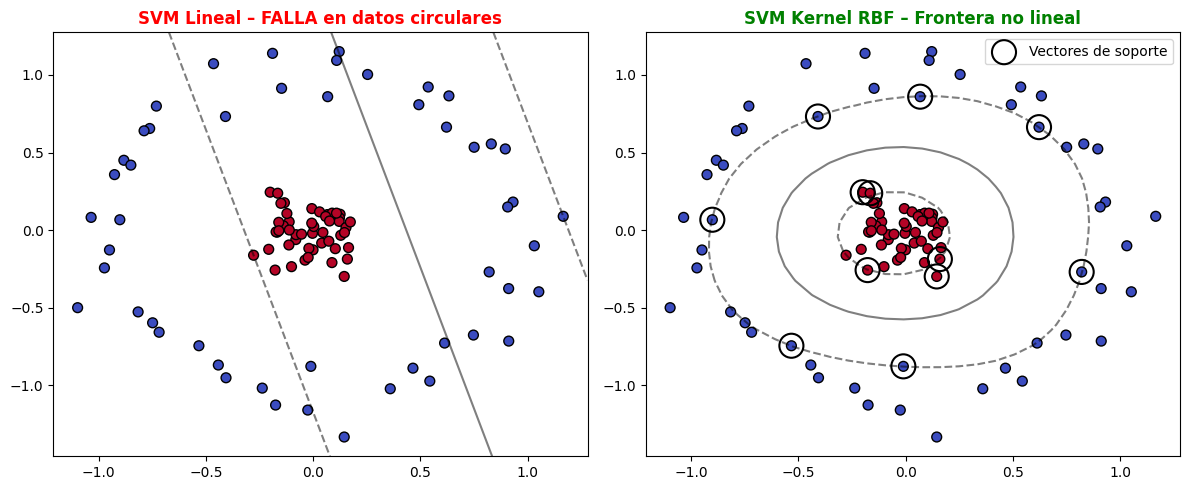

In [ ]:
from sklearn.datasets import make_circles

# Datos circulares (no separables linealmente)
X_circ, y_circ = make_circles(100, factor=0.1, noise=0.1, random_state=0)

fig, ejes = plt.subplots(1, 2, figsize=(12, 5))

# SVM lineal (falla)
svm_lin = SVC(kernel='linear').fit(X_circ, y_circ)
ejes[0].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='coolwarm', edgecolors='k', s=50)
graficar_svm(svm_lin, ejes[0], mostrar_soporte=False)
ejes[0].set_title('SVM Lineal – FALLA en datos circulares', color='red', fontweight='bold')

# SVM con kernel RBF (funciona)
svm_rbf = SVC(kernel='rbf').fit(X_circ, y_circ)
ejes[1].scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, cmap='coolwarm', edgecolors='k', s=50)
graficar_svm(svm_rbf, ejes[1], mostrar_soporte=True)
ejes[1].set_title('SVM Kernel RBF – Frontera no lineal', color='green', fontweight='bold')
ejes[1].legend()

plt.tight_layout()
plt.show()

## 4. Márgenes suaves y el parámetro de regularización $C$

Los datos del mundo real casi siempre presentan cierta superposición entre clases. Una máquina de vectores de soporte (SVM) con **margen estricto** (valor $C$ muy grande) exige una separación perfecta y puede sobreajustarse a datos ruidosos. Una SVM con **margen suave** (valor $C$ menor) tolera algunas clasificaciones erróneas a cambio de un margen más amplio y generalizable.

- **$C$ grande** → margen estrecho, menos clasificaciones erróneas en los datos de entrenamiento, riesgo de sobreajuste.

- **$C$ pequeño** → margen amplio, mayor tolerancia a las clasificaciones erróneas, mejor generalización.

Considere $C$ como un regulador entre *"obtener todos los puntos de entrenamiento correctos"* y *"mantener un margen amplio"*.

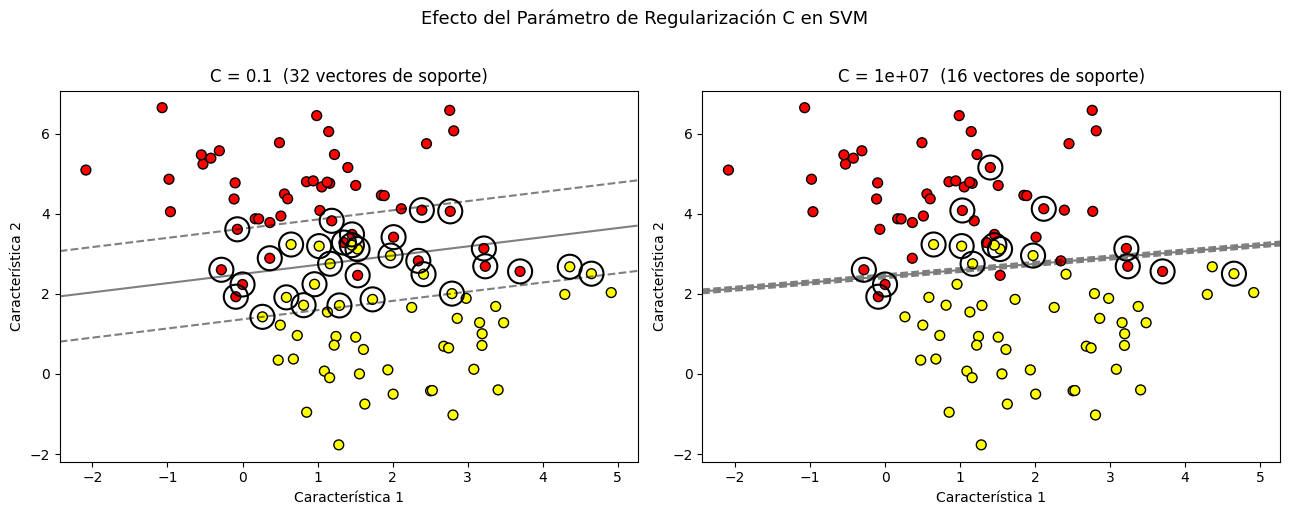

In [ ]:
X_solapado, y_solapado = make_blobs(n_samples=100, centers=2, random_state=0, cluster_std=1.2)

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

for ax, C_val in zip(ejes, [0.1, 1e7]):
    modelo_c = SVC(kernel='linear', C=C_val).fit(X_solapado, y_solapado)
    ax.scatter(X_solapado[:, 0], X_solapado[:, 1], c=y_solapado, cmap='autumn', edgecolors='k', s=50)
    graficar_svm(modelo_c, ax)
    ax.set_title(f'C = {C_val:g}  ({len(modelo_c.support_vectors_)} vectores de soporte)')
    ax.set_xlabel('Característica 1')
    ax.set_ylabel('Característica 2')

plt.suptitle('Efecto del Parámetro de Regularización C en SVM', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

> **Discusión:** En una tarea de clasificación de cobertura terrestre donde las etiquetas de entrenamiento provienen de la fotointerpretación visual (y por lo tanto contienen algunos errores de etiquetado), ¿elegirías un valor de $C$ grande o pequeño? ¿Por qué?

## 5. Evaluación de clasificadores binarios: Curvas ROC y AUC

En la lección anterior, presentamos la matriz de confusión, la precisión, el recall (la exhaustividad) y la puntuación F1. Aquí, añadimos dos herramientas de evaluación más, especialmente útiles para comprender el rendimiento del clasificador **en todos los posibles umbrales de decisión**.

### Tasa de verdaderos positivos y tasa de falsos positivos

Recal (también llamada **Tasa de verdaderos positivos**, TPR):

$$
\text{TPR} = \frac{TP}{TP + FN}
$$

Tasa de falsos positivos (False Postive Rate - FPR):

$$
\text{FPR} = \frac{FP}{FP + TN}
$$

### La curva ROC

Una **curva ROC (Curva Característica Operativa del Receptor)** representa la TPR frente a la FPR a medida que variamos el umbral de clasificación de 0 a 1. Cada umbral produce un par (FPR, TPR) diferente, trazando una curva.

- Un **clasificador perfecto** se sitúa en la esquina superior izquierda (TPR = 1, FPR = 0).

- Un **clasificador aleatorio** sigue la diagonal (TPR = FPR).

### AUC (Área bajo la curva ROC)

El AUC resume la curva ROC en un solo número:

| AUC | Interpretación |
|---|---|
| 1.0 | Separación perfecta |
| 0.7 – 0.9 | Discriminación buena a excelente |
| 0.5 | No mejor que una predicción aleatoria |
| < 0.5 | Peor que una predicción aleatoria (las predicciones están invertidas) |

El AUC es particularmente útil cuando las clases están desequilibradas, una situación común en ciencias ambientales (por ejemplo, detección de especies raras, ocurrencia de incendios forestales).

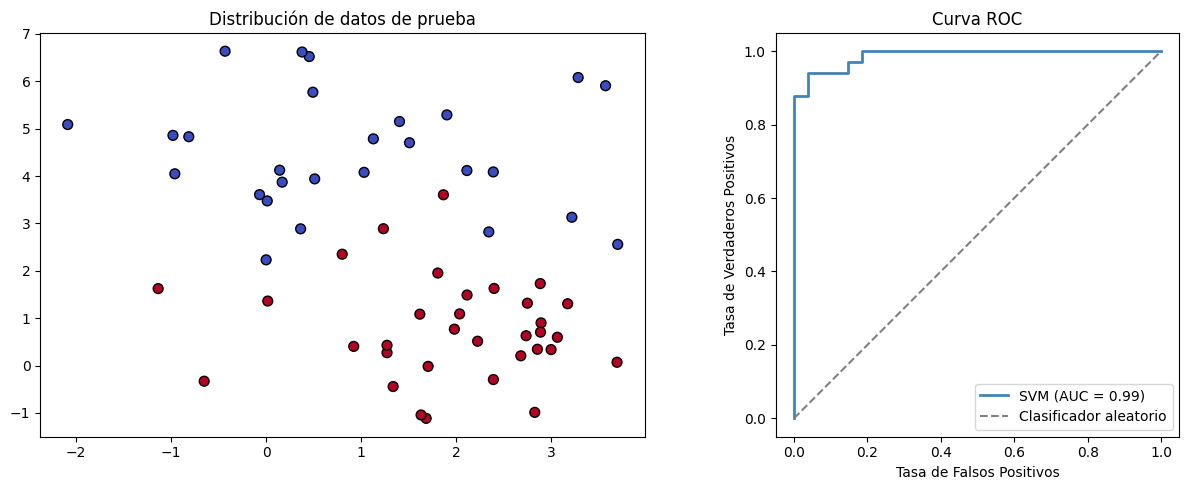

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score

# Generar datos superpuestos de dos clases
X_roc, y_roc = make_blobs(n_samples=200, centers=2, random_state=0, cluster_std=1.2)

# Dividir en conjunto de entrenamiento y prueba
X_tr, X_te, y_tr, y_te = train_test_split(X_roc, y_roc, test_size=0.3, random_state=42)

# Entrenar SVM con estimaciones de probabilidad habilitadas
modelo_roc = SVC(kernel='linear', C=10, probability=True)
modelo_roc.fit(X_tr, y_tr)

# Probabilidades previstas para la clase positiva
y_proba = modelo_roc.predict_proba(X_te)[:, 1]

# Calcular la curva ROC y el AUC
fpr, tpr, _ = roc_curve(y_te, y_proba)
auc_val = roc_auc_score(y_te, y_proba)

# ── Plot ──
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

# Datos de prueba
ejes[0].scatter(X_te[:, 0], X_te[:, 1], c=y_te, cmap='coolwarm', edgecolors='k', s=50)
ejes[0].set_title('Distribución de datos de prueba')

# Curva ROC
ejes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'SVM (AUC = {auc_val:.2f})')
ejes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
ejes[1].set_xlabel('Tasa de Falsos Positivos')
ejes[1].set_ylabel('Tasa de Verdaderos Positivos')
ejes[1].set_title('Curva ROC')
ejes[1].legend(loc='lower right')
ejes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### Contexto ecológico

Las curvas ROC se utilizan ampliamente en los modelos de distribución de especies (MDE) para evaluar la capacidad de un modelo para discriminar entre sitios donde una especie está presente y donde está ausente. Un AUC de 0,5 significa que el modelo no es mejor que lanzar una moneda al aire; los valores superiores a 0,8 generalmente se consideran útiles para la toma de decisiones de gestión.

> **Advertencia:** El AUC puede ser engañoso cuando el área de estudio es muy grande en relación con el área de distribución de la especie, ya que muchas ausencias "fáciles" inflan el rendimiento. Siempre combine el AUC con una evaluación con base ecológica (por ejemplo, un AUC parcial que se centre en una baja tasa de falsos positivos).

## 6. Aplicación: Clasificar Cobertura Forestal en el Perú

Usamos el dataset **Covertype** de scikit-learn (bosques de Colorado) como sustituto — en la práctica, usarías datos de parcelas forestales del SERFOR o MINAM con variables similares.

Problema binario: **Bosque denso (clase 1)** vs. **Bosque ralo/mixto (clase 2)**

In [ ]:
from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_auc_score, roc_curve
import numpy as np

covtype = fetch_covtype()
X_todo, y_todo = covtype.data, covtype.target

# Subset binario: clase 1 vs. clase 2
mascara = np.isin(y_todo, [1, 2])
X_bin   = X_todo[mascara]
y_bin   = (y_todo[mascara] == 2).astype(int)  # 0=Clase1, 1=Clase2

# Sub-muestra para velocidad (SVM es O(N²))
rng = np.random.RandomState(42)
idx = rng.choice(len(X_bin), size=2000, replace=False)
X_sub, y_sub = X_bin[idx], y_bin[idx]

print(f"Muestras: {len(X_sub)}")
print(f"Características: {X_sub.shape[1]}")
print(f"Balance: Clase 1 = {(y_sub == 0).sum()}, Clase 2 = {(y_sub == 1).sum()}")

Muestras: 2000
Características: 54
Balance: Clase 1 = 859, Clase 2 = 1141


In [ ]:
# Dividir y escalar
X_tr, X_te, y_tr, y_te = train_test_split(X_sub, y_sub, test_size=0.25, random_state=42, stratify=y_sub)

escalador = StandardScaler()
X_tr_e = escalador.fit_transform(X_tr)
X_te_e = escalador.transform(X_te)

# Entrenar SVM con kernel RBF
svm_modelo = SVC(kernel='rbf', C=10, gamma='scale', probability=True)
svm_modelo.fit(X_tr_e, y_tr)

# ── Evaluar ──
y_pred = svm_modelo.predict(X_te_e)
clases = ['Clase 1', 'Clase 2']

print("\nReporte de clasificación:")
print(classification_report(y_te, y_pred, target_names=clases))
print(f"Vectores de soporte: {svm_modelo.n_support_}")


Reporte de clasificación:
              precision    recall  f1-score   support

     Clase 1       0.74      0.76      0.75       215
     Clase 2       0.81      0.80      0.81       285

    accuracy                           0.78       500
   macro avg       0.78      0.78      0.78       500
weighted avg       0.78      0.78      0.78       500

Vectores de soporte: [409 425]


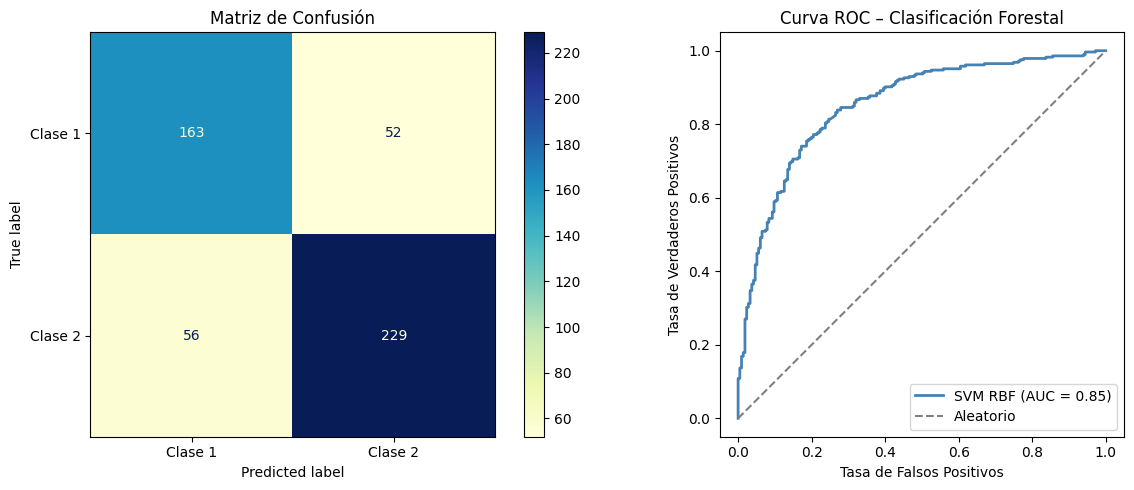

In [ ]:
# Matriz de confusión y curva ROC
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=clases,
                                         cmap='YlGnBu', ax=ejes[0])
ejes[0].set_title('Matriz de Confusión')

y_proba = svm_modelo.predict_proba(X_te_e)[:, 1]
fpr, tpr, _ = roc_curve(y_te, y_proba)
auc = roc_auc_score(y_te, y_proba)

ejes[1].plot(fpr, tpr, color='steelblue', linewidth=2, label=f'SVM RBF (AUC = {auc:.2f})')
ejes[1].plot([0, 1], [0, 1], '--', color='gray', label='Aleatorio')
ejes[1].set_xlabel('Tasa de Falsos Positivos')
ejes[1].set_ylabel('Tasa de Verdaderos Positivos')
ejes[1].set_title('Curva ROC – Clasificación Forestal')
ejes[1].legend(loc='lower right')
ejes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### Observaciones

Algunos puntos a destacar de este ejemplo:

- **La escala de las características es importante.** La máquina de vectores de soporte (SVM) con un núcleo RBF es sensible a la magnitud de las características. La elevación varía en miles, mientras que los índices de sombreado oscilan entre 0 y 255. Sin `StandardScaler`, el modelo estaría dominado por las características de mayor valor.

- **El núcleo RBF supera al lineal** en este conjunto de datos porque el límite entre el abeto/pícea y el pino contorta depende de interacciones no lineales entre la elevación, la orientación y el tipo de suelo.

> **Ejercicio:** Intente cambiar `C` (por ejemplo, 0.1, 1, 100) y observe cómo cambian el número de vectores de soporte y la precisión de la prueba. ¿Qué relación inversa observa?

---
## 7. SVM en Google Earth Engine: Clasificación de Cobertura del Suelo — Laguna Junín

Hasta ahora hemos utilizado `scikit-learn` con datos tabulares. En la práctica, uno de los usos más comunes de SVM en ciencias ambientales es la **clasificación de imágenes satelitales** en tipos de cobertura terrestre.

Google Earth Engine (GEE) proporciona un clasificador SVM integrado (`ee.Classifier.libsvm`) que se ejecuta en el servidor sobre pilas completas de imágenes, sin necesidad de descargar nada.

En este ejemplo vamos a clasificar la **Laguna Junín** (Lago Chinchaycocha, región Junín, ~4080 msnm), el segundo lago más grande del Perú:
1. Cargar un composito Sentinel-2 (alternativamente Landsat 8) sobre la Laguna Junín
2. Definir puntos de entrenamiento para 5 clases: agua, vegetación (bofedal/pastizal), suelo desnudo, pantano y urbano
3. Entrenar SVM lineal y RBF en las bandas espectrales
4. Clasificar la imagen y visualizar los resultados

> **Nota:** Esta sección requiere la autenticación GEE de Labs anteriores.

> Puedes revisar un timelapse en GEE: [Link](https://earthengine.google.com/timelapse/)

In [ ]:
# AUTENTICACIÓN (Ejecute esta celda y siga las instrucciones)
# # Esto abrirá una ventana del navegador donde deberá iniciar sesión en Google
# y otorgar permiso para que este cuaderno acceda a Earth Engine.

# # Solo necesita hacer esto una vez por sesión.
# Inicializar GEE
import ee, geemap
ee.Authenticate()
ee.Initialize(project='utec-ingambiental-01')  # <-- REEMPLAZA con tu Project ID #ee-cmillanarancibia utec-ingambiental-01

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


### 7.1 Landsat (alternativa)

In [ ]:
# Área de estudio: Laguna Junín (Lago Chinchaycocha) — región Junín, Perú
area_estudio = ee.Geometry.Rectangle([
    -76.27178926829023, -11.13708745225072,   # esquina suroeste (lon_min, lat_min)
    -75.99369783762617, -10.854665283162186   # esquina noreste  (lon_max, lat_max)
])

# Composito Landsat 8, época seca 2023
landsat = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
composito = (
    landsat
    .filterBounds(area_estudio)
    .filterDate('2025-05-01', '2025-09-30')  # <-- REEMPLAZA con tu rango de fechas
    .filter(ee.Filter.lt('CLOUD_COVER', 10))
    .select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'],
            ['Azul','Verde','Rojo','NIR','SWIR1','SWIR2'])
    .median()
    .clip(area_estudio)
)

Map = geemap.Map(basemap="Esri.WorldTopoMap")
Map.centerObject(area_estudio, zoom=12)
Map.addLayer(composito,
             {'bands':['Rojo','Verde','Azul'],'min':7000,'max':12000},
             'Composito Landsat 8 — Laguna Junín')
Map

Map(center=[-10.995885416319076, -76.13274355295805], controls=(WidgetControl(options=['position', 'transparen…

### 7.2 Sentinel-2 (usaremos esta para el resto del notebook)

In [ ]:
# Área de estudio: Laguna Junín (Lago Chinchaycocha) — región Junín, Perú
area_estudio = ee.Geometry.Rectangle([
    -76.27, -11.13,   # esquina suroeste (lon_min, lat_min)
    -75.99, -10.855   # esquina noreste  (lon_max, lat_max)
])

# Composito Sentinel-2, época seca 2023
sentinel = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')  # <-- REEMPLAZA con la colección que prefieras
composito = (
    sentinel
    .filterBounds(area_estudio)
    .filterDate('2025-05-01', '2025-09-30')  # <-- REEMPLAZA con tu rango de fechas
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
    .select(['B2','B3','B4','B8','B11','B12']) #,['Azul','Verde','Rojo','NIR','SWIR1','SWIR2']
)

# Median composite (reduces remaining cloud artifacts)
composito = composito.median().clip(area_estudio)

In [ ]:
# Los datos de la Colección 2 de Sentinel-2 requieren escalado.
# Los valores brutos son enteros; necesitamos convertirlos a reflectancia (0-1).

# Aplicar factores de escala
def escalar(img):
    """
    Aplicar factores de escala a la reflectancia superficial de la Colección 2 de Sentinel-2.
    La fórmula es: reflectancia = DN * 0.0001
    .multiply(0.0001)  # Escalar a reflectancia
    Esto convierte los números enteros almacenados en valores de reflectancia reales.
    """

    bandas_opt = ['B2','B3','B4','B8','B11','B12']
    opt = img.select(bandas_opt)

    escalada = opt.multiply(0.0001)
    return img.addBands(escalada, overwrite=True)

composito = escalar(composito)
print("Imagen escalada a valores de reflectancia (0–1)")

composito = composito.select(['B2','B3','B4','B8','B11','B12'],['Azul','Verde','Rojo','NIR','SWIR1','SWIR2'])

Imagen escalada a valores de reflectancia (0–1)


In [ ]:
Map = geemap.Map(basemap="Esri.WorldTopoMap")
Map.centerObject(area_estudio, zoom=12)
Map.addLayer(composito,
             {'bands':['Rojo','Verde','Azul'],'min':0,'max':0.15},
             'Composito Sentinel-2 — Laguna Junín')
Map

Map(center=[-10.992510650335468, -76.12999999999928], controls=(WidgetControl(options=['position', 'transparen…

### 7.3 Definir puntos de entrenamiento

| Codigo | Clase |
|--------|-------|
| 0 | Agua |
| 1 | Vegetación (bofedal / pastizal de puna) |
| 2 | Suelo desnudo |
| 3 | Pantano |
| 4 | Urbano |

### Recopilación interactiva de muestras de entrenamiento

En lugar de introducir coordenadas manualmente, podemos **hacer clic en el mapa** para recopilar puntos de entrenamiento. El flujo de trabajo es el siguiente:

1. Ejecuta la celda que aparece a continuación; esta añade un detector de clics al mapa y un selector de clase.

2. Selecciona una clase del menú desplegable (por ejemplo, "Agua").

3. Haz clic en el mapa para colocar puntos de entrenamiento para esa clase. Cada clic añade un marcador.

4. Cambia a la siguiente clase y repite el proceso.

5. Una vez finalizado, ejecuta la siguiente celda para convertir tus clics en una `ee.FeatureCollection`.

> **Consejo:** Utiliza el mapa base satelital y haz zoom para seleccionar píxeles claros (por ejemplo, el centro de la Laguna Junín para el agua, los bofedales de la orilla para vegetación).

In [ ]:
import ipywidgets as widgets
from IPython.display import display

# ── Definiciones de clases ──
class_labels = {
    'Agua': 0,
    'Pastar': 1,
    'Pastizales': 2,
    'Pantano': 3,
    'Urbano': 4,
    'pradera inundada' : 5
}
# Almacenamiento de puntos recopilados: {class_code: [(lon, lat), ...]}
collected_points = {v: [] for v in class_labels.values()}

# ── Menú desplegable para seleccionar la clase actual ──
class_dropdown = widgets.Dropdown(
    options=list(class_labels.keys()),
    value='Agua',
    description='Clase:',
    style={'description_width': 'initial'}
)

# ── Registro de salida ──
log_output = widgets.Output()

# ── Controlador de clics ──
def handle_map_click(**kwargs):
    if kwargs.get('type') == 'click':
        coords = kwargs.get('coordinates') # [lat, lon]
        lat, lon = coords[0], coords[1]
        current_class = class_labels[class_dropdown.value]
        collected_points[current_class].append((lon, lat))

        # Agregar un marcador al mapa
        from ipyleaflet import Marker, AwesomeIcon
        colors = {0: 'blue', 1: 'green', 2: 'orange', 3: 'gray', 4: 'black', 5: 'lightblue'}
        icon = AwesomeIcon(name='map-marker', marker_color=colors[current_class])
        marker = Marker(location=(lat, lon), icon=icon, draggable=False)
        Map.add(marker)

        with log_output:
            total = sum(len(v) for v in collected_points.values())
            print(f"[{class_dropdown.value}] Punto añadido ({lon:.4f}, {lat:.4f}) | Total: {total} puntos")

# Registrar el controlador de clic
Map.on_interaction(handle_map_click)

# ── Mostrar controles ──
botón_borrar = widgets.Button(description='Borrar todos los puntos', button_style='warning')

def on_clear(b):
    for k in collected_points:
        collected_points[k] = []
    with log_output:
        log_output.clear_output()
        print("Todos los puntos borrados. (Los marcadores permanecen en el mapa durante referencia.)")

botón_borrar.on_click(on_clear)

print("Haz clic en el mapa para obtener puntos de entrenamiento.")
print("Selecciona una clase del menú desplegable y luego haz clic en las ubicaciones del mapa.\n")
display(widgets.HBox([class_dropdown, botón_borrar]))
display(log_output)

Haz clic en el mapa para obtener puntos de entrenamiento.
Selecciona una clase del menú desplegable y luego haz clic en las ubicaciones del mapa.



Output()

In [ ]:
# ── Convertir los puntos clicados en un ee.FeatureCollection ──
class_names = {0: 'Agua',
               1: 'Pastar',
               2: 'Pastizales',
                3: 'Pantano',
               4: 'Urbano',
               5: 'pradera inundada'}

features = []
for class_code, points in collected_points.items():
    for lon, lat in points:
        feat = ee.Feature(ee.Geometry.Point([lon, lat]), {'landcover': class_code})
        features.append(feat)

puntos = ee.FeatureCollection(features)

# ── Summary ──
print("Training points collected:")
for class_code, points in collected_points.items():
    print(f"  {class_names[class_code]:15s}: {len(points)} points")
print(f"  {'TOTAL':15s}: {puntos.size().getInfo()} points")

Training points collected:
  Agua           : 5 points
  Pastar         : 2 points
  Pastizales     : 0 points
  Pantano        : 0 points
  Urbano         : 0 points
  pradera inundada: 0 points
  TOTAL          : 7 points


**Alternativa: puntos de entrenamiento predefinidos**

Si la función de clic interactivo no funciona (por ejemplo, al ejecutarlo en Colab sin compatibilidad con widgets), puede descomentar y usar estos puntos predefinidos para el área de estudio:

> Estos puntos fueron recolectados con el widget interactivo de la celda anterior (clic en el mapa sobre la Laguna Junín), por lo que ya están verificados visualmente. Se incluyen 5 clases: Agua, Vegetación, Suelo, Pantano y Urbano.

In [ ]:
# Puntos de entrenamiento recopilados interactivamente sobre la Laguna Junín (clic en el mapa)
agua = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-76.0944, -11.0103]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.1236, -11.0103]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.1531, -10.9971]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.1617, -11.0025]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.1085, -11.0527]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.0707, -11.0608]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.1795, -10.9896]), {'landcover': 0}),
    ee.Feature(ee.Geometry.Point([-76.1836, -10.9884]), {'landcover': 0}),
])
pastar = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-76.1461, -11.0895]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-76.1462, -11.0910]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-76.1747, -11.0958]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-76.1615, -11.0836]), {'landcover': 1}),
    ee.Feature(ee.Geometry.Point([-76.1608, -11.0835]), {'landcover': 1}),
])

pastizales = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-76.1551, -11.0962]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-76.1522, -11.0898]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-76.1533, -11.0897]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-76.0889, -10.8737]), {'landcover': 2}),
    ee.Feature(ee.Geometry.Point([-76.0839, -10.8788]), {'landcover': 2}),

])

pantano = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-76.1937, -11.0119]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1780, -11.0240]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1571, -11.0402]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.0836, -11.0922]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.0743, -11.0874]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.0432, -11.1010]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.0487, -11.1051]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.0495, -11.1033]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1593, -11.0419]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1592, -11.0384]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1649, -11.0388]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1727, -11.0341]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1703, -11.0306]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1746, -11.0285]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1792, -11.0230]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1867, -11.0207]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1957, -11.0105]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.2047, -11.0038]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.1991, -11.0026]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.2225, -10.9370]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.2155, -10.9370]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.2147, -10.9420]), {'landcover': 3}),
    ee.Feature(ee.Geometry.Point([-76.2265, -10.9420]), {'landcover': 3}),
])

urbano = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-76.0559, -10.9248]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0608, -10.9208]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0598, -10.9209]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0575, -10.9225]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0574, -10.9193]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0532, -10.9188]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0539, -10.9200]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0503, -10.9178]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0499, -10.9172]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0667, -10.9148]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.0655, -10.9135]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1135, -10.8652]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1119, -10.8640]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1120, -10.8615]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1135, -10.8608]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1123, -10.8589]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1123, -10.8577]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1470, -11.0860]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1494, -11.0843]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1474, -11.0837]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1467, -11.0839]), {'landcover': 4}),
    ee.Feature(ee.Geometry.Point([-76.1455, -11.0876]), {'landcover': 4}),
])

pradera_inundada = ee.FeatureCollection([
    ee.Feature(ee.Geometry.Point([-76.1303, -10.9309]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.1303, -10.9309]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.1430, -10.9322]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.1430, -10.9322]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.1365, -10.9403]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.1365, -10.9403]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.0111, -10.9139]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.0111, -10.9139]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.0116, -10.9144]), {'landcover': 5}),
    ee.Feature(ee.Geometry.Point([-76.0116, -10.9144]), {'landcover': 5})
])

puntos = agua.merge(pastar).merge(pastizales).merge(pantano).merge(urbano).merge(pradera_inundada)
print(f"Total puntos de entrenamiento: {puntos.size().getInfo()}")

Total puntos de entrenamiento: 73


In [ ]:
# Extraer valores espectrales y normalizar (importante para kernel RBF)
bandas = ['Azul','Verde','Rojo','NIR','SWIR1','SWIR2']

datos_entrenamiento = composito.select(bandas).sampleRegions(
    collection=puntos,
    properties=['landcover'],
    scale=10
).filter(ee.Filter.notNull(bandas))  # eliminar puntos sin datos (píxeles enmascarados)

# ── Normalizar las bandas (¡importante para el kernel RBF!) ──
means = composito.select(bandas).reduceRegion(
    reducer=ee.Reducer.mean(), geometry=area_estudio,
    scale=10, maxPixels=1e9
)
stds = composito.select(bandas).reduceRegion(
    reducer=ee.Reducer.stdDev(), geometry=area_estudio,
    scale=10, maxPixels=1e9
)

# Normalizar bandas z-score: (x - media) / desviación estándar
bandas_norm = [b+'_norm' for b in bandas]

composito_norm = ee.Image.cat([
    composito.select(b).subtract(ee.Number(means.get(b))).divide(ee.Number(stds.get(b))).rename(b+'_norm')
    for b in bandas
])

datos_entrenamiento_norm = composito_norm.sampleRegions(
    collection=puntos,
    properties=['landcover'],
    scale=10
).filter(ee.Filter.notNull(bandas_norm))  # eliminar puntos sin datos

print("Se crearon bandas normalizadas y se remuestrearon los datos de entrenamiento.")

Se crearon bandas normalizadas y se remuestrearon los datos de entrenamiento.


### Verificación de puntos: Firmas espectrales

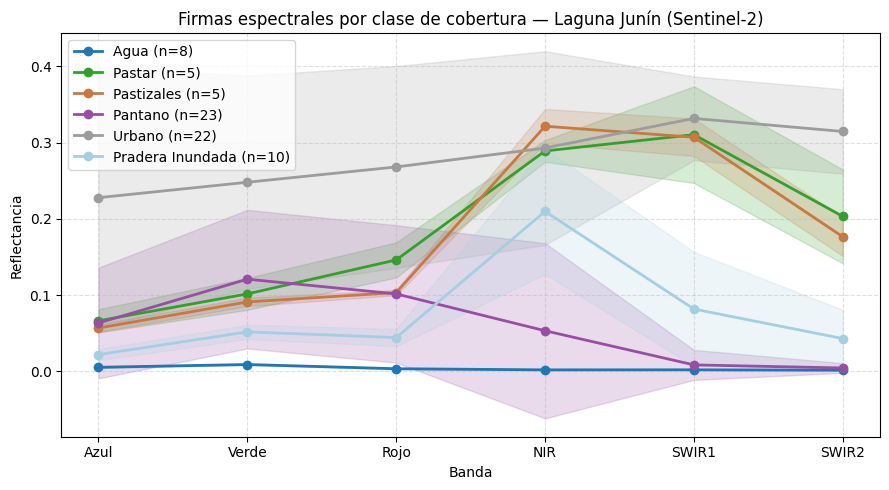

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir muestras a DataFrame local
info = datos_entrenamiento.getInfo()
df = pd.DataFrame([f['properties'] for f in info['features']])

class_names = {0: 'Agua', 1: 'Pastar', 2: 'Pastizales', 3: 'Pantano', 4: 'Urbano', 5: 'Pradera Inundada'}
colores     = {0: '#1f78b4', 1: '#33a02c', 2: '#c87941', 3: '#984ea3', 4: "#9c9c9c", 5: '#a6cee3'}

fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(bandas))
for code, nombre in class_names.items():
    subset = df[df['landcover'] == code][bandas]
    media = subset.mean()
    std   = subset.std()
    ax.plot(x, media, color=colores[code], marker='o', linewidth=2, label=f'{nombre} (n={len(subset)})')
    ax.fill_between(x, media - std, media + std, color=colores[code], alpha=0.2)

ax.set_xticks(x)
ax.set_xticklabels(bandas)
ax.set_xlabel('Banda')
ax.set_ylabel('Reflectancia')
ax.set_title('Firmas espectrales por clase de cobertura — Laguna Junín (Sentinel-2)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

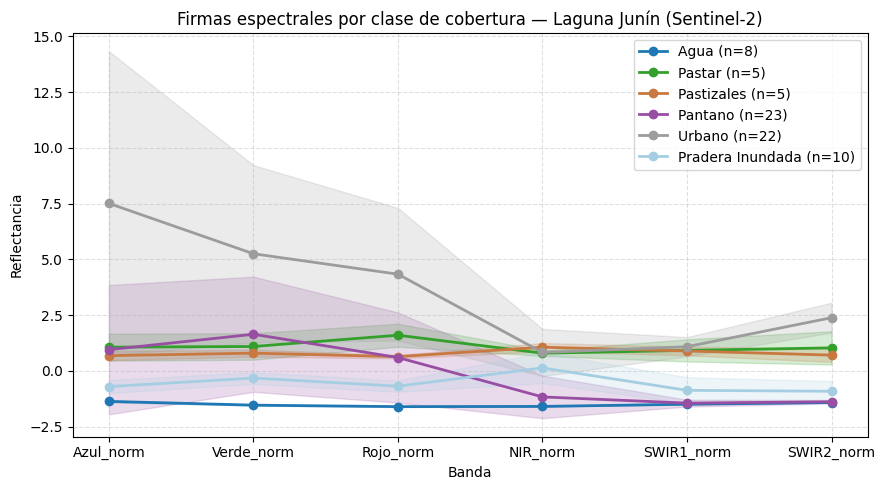

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir muestras a DataFrame local
info = datos_entrenamiento_norm.getInfo()
df = pd.DataFrame([f['properties'] for f in info['features']])

class_names = {0: 'Agua', 1: 'Pastar', 2: 'Pastizales', 3: 'Pantano', 4: 'Urbano', 5: 'Pradera Inundada'}
colores     = {0: '#1f78b4', 1: '#33a02c', 2: '#c87941', 3: '#984ea3', 4: "#9c9c9c", 5: '#a6cee3'}

fig, ax = plt.subplots(figsize=(9, 5))

x = range(len(bandas_norm))
for code, nombre in class_names.items():
    subset = df[df['landcover'] == code][bandas_norm]
    media = subset.mean()
    std   = subset.std()
    ax.plot(x, media, color=colores[code], marker='o', linewidth=2, label=f'{nombre} (n={len(subset)})')
    ax.fill_between(x, media - std, media + std, color=colores[code], alpha=0.2)

ax.set_xticks(x)
ax.set_xticklabels(bandas_norm)
ax.set_xlabel('Banda')
ax.set_ylabel('Reflectancia')
ax.set_title('Firmas espectrales por clase de cobertura — Laguna Junín (Sentinel-2)')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
# ── Entrenar SVM con kernel lineal y kernel RBF en GEE ──

# 1) Núcleo lineal (bandas crudas — menos sensible al escalado)
svm_lineal = ee.Classifier.libsvm(
    kernelType='LINEAR', cost=10
).train(datos_entrenamiento, classProperty='landcover', inputProperties=bandas)

# 2) Núcleo RBF sin normalizar (para mostrar que el escalado importa)
svm_rbf = ee.Classifier.libsvm(
    kernelType='RBF', cost=10, gamma=0.5
).train(datos_entrenamiento, classProperty='landcover', inputProperties=bandas)

# 3) Núcleo RBF normalizado — gamma bajo + z-score (mejor generalización)
svm_rbf_norm = ee.Classifier.libsvm(
    kernelType='RBF', cost=10, gamma=0.01
).train(datos_entrenamiento_norm, classProperty='landcover', inputProperties=bandas_norm)

print("Tres clasificadores SVM entrenados:")
print(" 1. Lineal          — bandas crudas")
print(" 2. RBF sin escalar — bandas crudas, gamma=0.5")
print(" 3. RBF normalizado — z-score,       gamma=0.01")

Tres clasificadores SVM entrenados:
 1. Lineal          — bandas crudas
 2. RBF sin escalar — bandas crudas, gamma=0.5
 3. RBF normalizado — z-score,       gamma=0.01


In [ ]:
# Clasificar
clasi_lineal   = composito.select(bandas).classify(svm_lineal)
clasi_rbf      = composito.select(bandas).classify(svm_rbf)       # bandas crudas
clasi_rbf_norm = composito_norm.classify(svm_rbf_norm)            # bandas normalizadas

paleta = ['#1f78b4',"#d2d42c",'#c87941','#7ec841','#9c9c9c','#b18748']  # Agua, Pastar, Pastizales, Pantano, Urbano, Pradera Inundada

Map2 = geemap.Map(basemap="Esri.WorldTopoMap")
Map2.centerObject(area_estudio, zoom=12)
Map2.addLayer(composito,
                    {'bands':['Rojo','Verde','Azul'],'min':0,'max':0.15},
                    'Sentinel-2 base — Laguna Junín')
Map2.addLayer(clasi_lineal,
                    {'min':0,'max':5,'palette':paleta},
                    'SVM Lineal')
Map2.addLayer(clasi_rbf,
                    {'min':0,'max':5,'palette':paleta},
                    'SVM RBF (sin normalizar)')
Map2.addLayer(clasi_rbf_norm,
                    {'min':0,'max':5,'palette':paleta},
                    'SVM RBF (normalizado)')
Map2.add_legend(
    title='Cobertura',
    keys=['Agua','Pastar','Pastizales','Pantano','Urbano','Pradera Inundada'],
    colors=paleta
)
Map2

Map(center=[-10.992510650335468, -76.12999999999928], controls=(WidgetControl(options=['position', 'transparen…

### ¿Por qué falla el kernel RBF con la configuración predeterminada?

Active o desactive las capas clasificadas en el mapa superior. Probablemente observará que la capa "RBF (gamma=0.5, raw)" presenta ruido o clasifica la mayor parte de la imagen como una sola clase, mientras que las capas lineal y RBF mejorada producen mapas más coherentes. Esto se debe a tres problemas interrelacionados:

**1. Falta de escalado de características.** El kernel RBF calcula distancias en el espacio de características: $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \| \mathbf{x} - \mathbf{x}' \|^2)$. Los valores de reflectancia superficial de Landsat/Sentinel 2 difieren en magnitud entre las bandas: NIR y SWIR pueden alcanzar decenas de miles, mientras que el azul se mantiene por debajo. Sin normalización, la distancia del kernel está dominada por la banda con los valores más altos, y las demás bandas apenas contribuyen. El kernel lineal es menos sensible porque calcula productos escalares en lugar de distancias.

**2. Gamma demasiado alto.** El parámetro `gamma` controla el radio de influencia de cada vector de soporte. Un valor alto de gamma implica que cada punto de entrenamiento solo afecta a un vecindario pequeño: el modelo crea regiones de decisión muy estrechas alrededor de los 20 píxeles de entrenamiento y todo lo demás se clasifica en una clase predeterminada. Esto se conoce como **sobreajuste en el espacio de características**, análogo al polinomio de grado 15 de la Lección anterior.

**3. Puntos de entrenamiento insuficientes.** Con solo ~5 puntos por clase, no hay suficiente información para que un modelo flexible como RBF-SVM aprenda un límite generalizable. El kernel lineal, al ser más restringido (menor varianza), se adapta mejor a tamaños de muestra pequeños.

El clasificador RBF mejorado aborda los tres problemas: utiliza **bandas normalizadas por puntuación z** y un **gamma más bajo** (0,01), lo que otorga a cada vector de soporte una influencia más amplia y permite que todas las bandas espectrales contribuyan por igual al cálculo de la distancia.

| Configuración | gamma | Escalado | Comportamiento |
|---|---|---|---|
| RBF (deficiente) | 0.5 | Ninguno | Sobreajuste; mapa ruidoso o de una sola clase |
| RBF (mejor) | 0.01 | Puntuación Z | Límites más suaves y generalizables |
| Lineal | n/a | Ninguno | Robusto con pocas muestras, pero no puede capturar límites no lineales |

> **Lección:** Un modelo más potente no es automáticamente un mejor modelo. RBF-SVM tiene mayor capacidad que SVM lineal, pero esa capacidad se convierte en una desventaja cuando los datos de entrenamiento son escasos, las características no están escaladas o los hiperparámetros están mal elegidos. Este es el **compromiso entre sesgo y varianza** en acción.

---
### ¿Cómo podemos aumentar la información para nuestro modelo?

Hasta ahora hemos usado únicamente las seis bandas espectrales originales (Azul, Verde, Rojo, NIR, SWIR1, SWIR2) como variables de entrada para el SVM. Pero no estamos obligados a usar solo las bandas crudas: podemos **generar nueva información a partir de los datos que ya tenemos**, combinando bandas mediante operaciones matemáticas que resaltan procesos físicos específicos. A estas combinaciones se las llama **índices espectrales**.

Dos ejemplos clásicos:

- **NDVI** (Índice de Vegetación de Diferencia Normalizada):
$$
\text{NDVI} = \frac{NIR - Rojo}{NIR + Rojo}
$$
resalta la vegetación viva (valores altos) frente a agua, suelo desnudo o superficies urbanas (valores bajos o negativos).

- **AWEI**$_{nsh}$ (Automated Water Extraction Index, versión sin sombras):
$$
\text{AWEI}_{nsh} = 4\,(Verde - SWIR1) - (0.25 \cdot NIR + 2.75 \cdot SWIR2)
$$
diseñado específicamente para separar agua de otras coberturas, incluso en presencia de sombras o sustratos oscuros que suelen confundir a índices de agua más simples (como NDWI).

Agregar estos índices como bandas adicionales le da al clasificador más "pistas" no lineales derivadas de las mismas seis bandas originales — en la práctica, suele mejorar la separabilidad entre clases que el SVM ya intenta encontrar, especialmente para distinguir Agua/Pantano (donde el AWEI ayuda) o Vegetación/Suelo (donde ayuda el NDVI).

> Existen decenas de índices espectrales documentados para distintos propósitos (vegetación, agua, suelo, quemas, nieve, etc.). El catálogo [**Awesome Spectral Indices**](https://awesome-ee-spectral-indices.readthedocs.io/en/latest/index.html) reúne cientos de ellos, listos para usar en Google Earth Engine, junto con sus fórmulas y referencias bibliográficas.

In [ ]:
# ── Calcular índices espectrales y añadirlos como bandas ──

def agregar_indices(img):
    ndvi = img.normalizedDifference(['NIR', 'Rojo']).rename('NDVI')
    awei_nsh = img.expression(
        '4 * (G - S1) - (0.25 * N + 2.75 * S2)',
        {
            'G':  img.select('Verde'),
            'S1': img.select('SWIR1'),
            'N':  img.select('NIR'),
            'S2': img.select('SWIR2'),
        }
    ).rename('AWEInsh')
    return img.addBands([ndvi, awei_nsh])

composito = agregar_indices(composito)

bandas_idx = bandas + ['NDVI', 'AWEInsh']
print("Bandas disponibles ahora:", bandas_idx)

Bandas disponibles ahora: ['Azul', 'Verde', 'Rojo', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'AWEInsh']


In [ ]:
# ── Extraer datos de entrenamiento con las bandas + índices, y normalizar (z-score) ──
datos_entrenamiento_idx = composito.select(bandas_idx).sampleRegions(
    collection=puntos,
    properties=['landcover'],
    scale=10
).filter(ee.Filter.notNull(bandas_idx))

means_idx = composito.select(bandas_idx).reduceRegion(
    reducer=ee.Reducer.mean(), geometry=area_estudio, scale=10, maxPixels=1e9
)
stds_idx = composito.select(bandas_idx).reduceRegion(
    reducer=ee.Reducer.stdDev(), geometry=area_estudio, scale=10, maxPixels=1e9
)

bandas_idx_norm = [b + '_norm' for b in bandas_idx]
composito_idx_norm = ee.Image.cat([
    composito.select(b).subtract(ee.Number(means_idx.get(b))).divide(ee.Number(stds_idx.get(b))).rename(b + '_norm')
    for b in bandas_idx
])

datos_entrenamiento_idx_norm = composito_idx_norm.sampleRegions(
    collection=puntos,
    properties=['landcover'],
    scale=10
).filter(ee.Filter.notNull(bandas_idx_norm))

print("Datos de entrenamiento extendidos con NDVI y AWEInsh, normalizados por z-score.")

Datos de entrenamiento extendidos con NDVI y AWEInsh, normalizados por z-score.


In [ ]:
# ── Entrenar SVM RBF normalizado con el espacio de características ampliado ──
svm_rbf_idx = ee.Classifier.libsvm(
    kernelType='RBF', cost=10, gamma=0.01
).train(datos_entrenamiento_idx_norm, classProperty='landcover', inputProperties=bandas_idx_norm)

clasi_rbf_idx = composito_idx_norm.classify(svm_rbf_idx)

Map3 = geemap.Map(basemap="Esri.WorldTopoMap")
Map3.centerObject(area_estudio, zoom=12)
Map3.addLayer(composito,
              {'bands': ['Rojo', 'Verde', 'Azul'], 'min': 0, 'max': 0.15},
              'Sentinel-2 base — Laguna Junín')
Map3.addLayer(clasi_rbf_norm,
              {'min': 0, 'max': 5, 'palette': paleta},
              'SVM RBF norm')
Map3.addLayer(clasi_rbf_idx,
              {'min': 0, 'max': 5, 'palette': paleta},
              'SVM RBF norm + Index')
Map3.add_legend(
    title='Cobertura',
    keys=['Agua','Pastar','Pastizales','Pantano','Urbano','Pradera Inundada'],
    colors=paleta
)
Map3

Map(center=[-10.992510650335468, -76.12999999999928], controls=(WidgetControl(options=['position', 'transparen…

Compara visualmente ambas capas clasificadas (activa/desactiva en el panel de capas del mapa): **"solo 6 bandas"** vs. **"6 bandas + NDVI + AWEInsh"**. ¿Cambia la delimitación de Agua o Pantano al incluir el índice de agua? ¿Cambia el límite entre Vegetación y Suelo al incluir el NDVI?

---
### Calcular el área de cada clase

Antes de exportar, calculamos cuántos km² (y hectáreas) ocupa cada clase de cobertura dentro del área de estudio, usando la clasificación SVM RBF normalizada con índices espectrales (`clasi_rbf_idx`, la versión "6 bandas + NDVI + AWEInsh" del mapa anterior). Usamos `ee.Image.pixelArea()` agrupado por el valor de clase con `ee.Reducer.sum().group(...)` — el mismo patrón de agrupamiento que ya usamos para las firmas espectrales, pero sumando área en vez de promediar bandas.

Guardamos el resultado en un CSV para reportes o para compararlo con la clasificación de K-Means de la tarea anterior.

In [ ]:
# ── Calcular área (m², ha, km²) por clase antes de exportar ──
img_area_clase = ee.Image.pixelArea().rename('area_m2').addBands(clasi_rbf_idx.rename('Clases'))

reductor_area = ee.Reducer.sum().group(groupField=1, groupName='Clases')

stats_area = img_area_clase.select(['area_m2', 'Clases']).reduceRegion(
    reducer=reductor_area,
    geometry=area_estudio,
    scale=10,
    maxPixels=1e9
)

grupos_area = stats_area.get('groups').getInfo()

filas_area = []
for g in grupos_area:
    clase_id = g['Clases']
    area_m2 = g['sum']
    filas_area.append({
        'clase_id': clase_id,
        'clase': class_names.get(clase_id, 'Indefinido'),
        'color': paleta[clase_id],
        'area_m2': area_m2,
        'area_ha': area_m2 / 1e4,
        'area_km2': area_m2 / 1e6,
    })

df_areas = pd.DataFrame(filas_area).sort_values('clase_id').reset_index(drop=True)
df_areas['porcentaje'] = 100 * df_areas['area_km2'] / df_areas['area_km2'].sum()

print(df_areas.round(2))

df_areas.to_csv('LagunaJunin_SVM_AreasPorClase.csv', index=False)
print("\nGuardado: LagunaJunin_SVM_AreasPorClase.csv")

   clase_id             clase    color       area_m2   area_ha  area_km2  \
0         0              Agua  #1f78b4  1.453895e+08  14538.95    145.39   
1         1            Pastar  #d2d42c  9.926178e+07   9926.18     99.26   
2         2        Pastizales  #c87941  3.648164e+08  36481.64    364.82   
3         3           Pantano  #7ec841  4.694187e+07   4694.19     46.94   
4         4            Urbano  #9c9c9c  3.284625e+06    328.46      3.28   
5         5  Pradera Inundada  #b18748  2.711939e+08  27119.39    271.19   

   porcentaje  
0       15.62  
1       10.66  
2       39.19  
3        5.04  
4        0.35  
5       29.13  

Guardado: LagunaJunin_SVM_AreasPorClase.csv


### Exportar la imagen clasificada

Agregamos la clasificación (`clasi_rbf_idx`, SVM RBF normalizado con NDVI y AWEInsh) como una banda llamada **"Clases"** al composito y la exportamos a Google Drive en formato GeoTIFF. Esto permite abrir el resultado en QGIS, ArcGIS o cualquier otro SIG para análisis posterior (validación de campo, superposición con otras capas, etc.).

In [ ]:
# ── Exportar la imagen clasificada (banda "Clases") a Google Drive ──────────
imagen_exportar = composito.select(bandas_idx).addBands(clasi_rbf_idx.rename('Clases'))

tarea_exportar = ee.batch.Export.image.toDrive(
    image=imagen_exportar,
    description='LagunaJunin_SVM_Clases',
    folder='GEE_exports',                       # <-- carpeta en tu Google Drive (se crea si no existe)
    fileNamePrefix='LagunaJunin_SVM_Clases',
    region=area_estudio,
    scale=10,
    maxPixels=1e9
)
#tarea_exportar.start()

print("Tarea de exportación iniciada.")
print("Bandas exportadas:", bandas_idx + ['Clases'])
print("Revisa el progreso (puede tardar varios minutos) en:")
print("  https://code.earthengine.google.com/tasks")
print("El archivo aparecerá en tu Google Drive, carpeta 'GEE_exports', como:")
print("  LagunaJunin_SVM_Clases.tif")

Tarea de exportación iniciada.
Bandas exportadas: ['Azul', 'Verde', 'Rojo', 'NIR', 'SWIR1', 'SWIR2', 'NDVI', 'AWEInsh', 'Clases']
Revisa el progreso (puede tardar varios minutos) en:
  https://code.earthengine.google.com/tasks
El archivo aparecerá en tu Google Drive, carpeta 'GEE_exports', como:
  LagunaJunin_SVM_Clases.tif


---
## 🔬 Ejercicio

Usando el clasificador SVM entrenado:

1. Cambia el valor de `C` (prueba 0.1, 1, 100) y observa cómo cambia el número de vectores de soporte y la exactitud de prueba.
2. Prueba con `kernel='linear'` vs. `kernel='rbf'` y compara el AUC.
3. ¿Por qué es importante el escaldo de características para SVM con kernel RBF?

> **Contexto ambiental:** En monitoreo de deforestación, el **recall** para la clase "deforestado" es más crítico que la precisión — es preferible una falsa alarma que dejar pasar la deforestación real.

In [ ]:
# Tu código aquí
# Prueba diferentes valores de C
print(f"{'C':>8} {'Exactitud':>12} {'AUC':>8} {'N vectores soporte':>20}")
print("-" * 50)

for C_val in [0.1, 1, 10, 100]:
    svm_c = SVC(kernel='rbf', C=C_val, gamma='scale', probability=True)
    svm_c.fit(X_tr_e, y_tr)
    exactitud = svm_c.score(X_te_e, y_te)
    auc_c = roc_auc_score(y_te, svm_c.predict_proba(X_te_e)[:, 1])
    n_sv  = sum(svm_c.n_support_)
    print(f"{C_val:>8} {exactitud:>12.3f} {auc_c:>8.3f} {n_sv:>20}")

       C    Exactitud      AUC   N vectores soporte
--------------------------------------------------
     0.1        0.694    0.816                 1225
       1        0.762    0.845                  947
      10        0.784    0.854                  834
     100        0.784    0.842                  758


---
## 8. Resumen

| Concepto | Conclusión clave |
|----------|------------------|
| Objetivo de SVM | Encontrar el hiperplano de margen máximo que separa dos clases |
| Vectores de soporte | Los puntos de entrenamiento en los límites del margen; ellos solos definen el hiperplano |
| Truco del kernel | Mapea datos a dimensiones superiores implícitamente, habilitando fronteras no lineales |
| Kernel RBF | $K(\mathbf{x}, \mathbf{x}') = \exp(-\gamma \|\mathbf{x}-\mathbf{x}'\|^2)$; uso general, buen punto de partida |
| Parámetro $C$ | C pequeño → margen ancho (puede subajustar); C grande → margen estrecho (puede sobreajustar) |
| Curva ROC | Grafica TVP vs. TFP en todos los umbrales; un buen clasificador se curva hacia arriba-izquierda |
| AUC | Resumen numérico de la curva ROC; 1.0 = perfecto, 0.5 = aleatorio |
| Escalado | **Obligatorio** — SVM con kernel RBF usa distancias, sensible a la escala |
| Aplicación en Perú | Clasificación supervisada de la **Laguna Junín**: agua, vegetación, suelo, urbano |

### Cuándo usar SVM

Las SVM funcionan bien cuando el número de características es grande en relación con el número de muestras (algo común en aplicaciones de teledetección) y cuando se busca un clasificador robusto con sólidos fundamentos teóricos. Son menos convenientes para conjuntos de datos muy grandes y no generan estimaciones de probabilidad por defecto (aunque `scikit-learn` puede estimarlas mediante el escalado de Platt con `probability=True`).

---
## 📝 Tarea — Clasificación supervisada de un glaciar peruano con SVM

Aplica el **mismo flujo de trabajo** de la sección 7, pero ahora sobre un **glaciar peruano**, usando SVM (en lugar de K-Means no supervisado de la tarea anterior).

**Glaciar sugerido:** Coropuna (Arequipa) — el mismo que usaste en la tarea de K-Means, para poder comparar ambos enfoques sobre la misma área. Puedes usar otro glaciar si lo prefieres (Pastoruri en Áncash, Quelccaya en Cusco, algún nevado de la Cordillera Vilcanota, etc.) — solo ajusta las coordenadas.

### Clases sugeridas para el glaciar

| Código | Clase |
|--------|-------|
| 0 | Agua (lagunas proglaciares) |
| 1 | Nieve / Hielo |
| 2 | Roca expuesta / morrena |
| 3 | Pastizal ralo (zonas bajas) |

### Pasos a seguir

1. **Definir el área de estudio** del glaciar (celda de partida más abajo, reutiliza las coordenadas de tu tarea de K-Means).
2. **Cargar y visualizar** un composito Sentinel-2 de época seca.
3. **Recolectar puntos de entrenamiento** (clic interactivo o predefinidos) para las 4 clases — recuerda **verificar visualmente** cada punto antes de entrenar.
4. **Extraer valores espectrales y normalizar** (igual que hicimos para la Laguna Junín).
5. **Entrenar al menos dos clasificadores SVM**: uno lineal y uno RBF (con y sin normalizar, para comparar igual que en la sección 7).
6. **Clasificar la imagen completa** y visualizar en el mapa con leyenda.
7. **Comparar con tu resultado de K-Means** (tarea anterior): ¿coinciden las clases? ¿Cuál te parece más confiable y por qué?

> **Pista clave:** la nieve/hielo es muy brillante en el visible y muy oscura en SWIR — un contraste fuerte que debería facilitar la separación con SVM lineal incluso sin kernel RBF.

In [ ]:
# ── Configuración: área de estudio del glaciar (misma que en la tarea de K-Means) ──
import ee, geemap
ee.Authenticate()
ee.Initialize(project='utec-ingambiental-01')  # <-- REEMPLAZA con tu Project ID ee-cmillanarancibia

# Glaciar Coropuna (Arequipa)
LON_MIN_G, LAT_MIN_G = -72.766883, -15.417441
LON_MAX_G, LAT_MAX_G = -72.508209, -15.65

area_glaciar = ee.Geometry.Rectangle([LON_MIN_G, LAT_MIN_G, LON_MAX_G, LAT_MAX_G])

composito_g = (
    ee.ImageCollection('NASA/HLS/HLSL30/v002')
    .filterBounds(area_glaciar)
    .filterDate('2025-05-01', '2025-09-30')
    #.filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .select(['B2','B3','B4','B5','B6','B7'])
    .median()
    .clip(area_glaciar)
)
composito_g = composito_g.select(
    ['B2','B3','B4','B5','B6','B7'], ['Azul','Verde','Rojo','NIR','SWIR1','SWIR2']
)

Map_g = geemap.Map(basemap="Esri.WorldTopoMap")
Map_g.centerObject(area_glaciar, zoom=13)
Map_g.addLayer(composito_g, {'bands':['Rojo','Verde','Azul'],'min':0,'max':0.6}, 'Sentinel-2 — Glaciar')
Map_g

Map(center=[-15.533736301309277, -72.63754600000026], controls=(WidgetControl(options=['position', 'transparen…

### Tu turno

Completa las celdas siguientes siguiendo el mismo patrón usado para la Laguna Junín (sección 7).

In [ ]:
# TU CÓDIGO AQUÍ — Paso 3: recolectar puntos de entrenamiento para las 4 clases del glaciar
# Pista: reutiliza el widget interactivo de la sección 7, o define puntos predefinidos
#        con ee.Feature(ee.Geometry.Point([lon, lat]), {'landcover': codigo})


In [ ]:
# TU CÓDIGO AQUÍ — Paso 4: extraer valores espectrales y normalizar (z-score)
# Pista: reutiliza sampleRegions + reduceRegion(mean/stdDev), igual que con la Laguna Junín


In [ ]:
# TU CÓDIGO AQUÍ — Paso 5: entrenar SVM lineal y RBF (con y sin normalizar)
# Pista: ee.Classifier.libsvm(kernelType=..., cost=..., gamma=...)


In [ ]:
# TU CÓDIGO AQUÍ — Paso 6: clasificar la imagen completa y visualizar con leyenda
# Pista: composito_g.classify(modelo) + geemap.Map().addLayer(...) + Map.add_legend(...)


### Para tu informe

Responde brevemente (puedes usar esta misma celda en formato Markdown):

1. ¿Qué kernel (lineal o RBF) dio un mapa más coherente para el glaciar? ¿Por qué crees que ocurrió eso?
2. Compara el mapa de SVM con el de K-Means (tarea anterior, mismo glaciar). ¿Las clases de "nieve/hielo" coinciden espacialmente?
3. ¿Qué ventaja tiene SVM (supervisado) sobre K-Means (no supervisado) para este problema? ¿Y qué desventaja?